In [ ]:
!pip install openpyxl

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


Original shape: (7129, 97)
After cleaning: (7129, 96)
After transpose: (96, 7129)
After duplicate handling: (96, 5663)
Cancer shape: (86, 5663)
Normal shape: (10, 5663)
Genes: 5663
Scores: 5663

Top Genes by Multi-Eigen Contribution:
           Gene     Score
4925      SOX20  0.982364
5181       TFF1  0.961283
837         CGA  0.960912
1624        FGB  0.948614
607       CALCA  0.926443
1944      GPM6B  0.925171
4577      S100P  0.921549
1011       CPS1  0.921212
2484        IL6  0.919756
5250     TM4SF4  0.917460
1236      DEFA1  0.913796
1575      FABP4  0.909048
4661       SELE  0.900869
4317      RAP2B  0.900780
1973       GPX2  0.898962
5479       USP4  0.896526
3608       ODC1  0.896487
5182       TFF2  0.894353
2280  HSAPOMUCN  0.886231
5437      UCHL1  0.884889

===== SCORE STATISTICS =====
Max Difference   : 0.982363512599233
Min Difference   : 5.139494919406769e-05
Average Difference: 0.28724298692125005
Std Deviation    : 0.20466518870376846

Chosen Threshold: 0.5

Total Gen

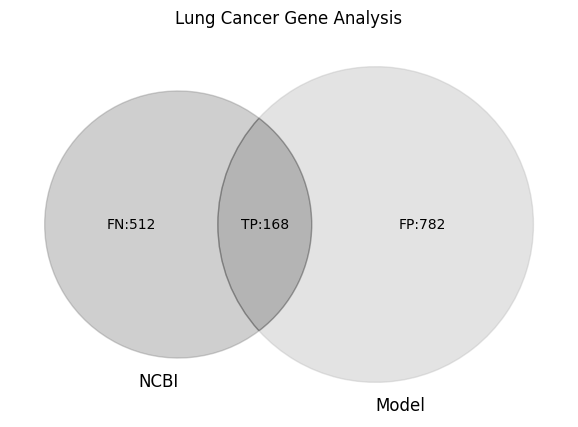

In [ ]:
# ================================
# STEP 0: Imports
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# ================================
# STEP 1: Load Data
# ================================
df = pd.read_excel("/content/drive/MyDrive/gene_expression_data_for_Lung.xlsx")

print("Original shape:", df.shape)

# STEP 2: Clean Data (SAFE)

# Rename first column properly
df.rename(columns={df.columns[0]: "GENE"}, inplace=True)

# Remove rows where gene name is missing
df["GENE"] = df["GENE"].astype(str).str.strip()

df = df[
    df["GENE"].notna() &
    (df["GENE"].str.upper() != "NULL") &
    (df["GENE"] != "")
]

# Set gene column as index
df.set_index("GENE", inplace=True)

print("After cleaning:", df.shape)

# STEP 3: Transpose

data = df.T

print("After transpose:", data.shape)

# STEP 4: FIX DATA TYPES

data = data.apply(pd.to_numeric, errors='coerce').fillna(0)

# Convert column names to string
data.columns = data.columns.astype(str)

# STEP 5: REMOVE DUPLICATES (SAFE)

if data.columns.duplicated().sum() > 0:
    data = data.T.groupby(level=0).mean().T

print("After duplicate handling:", data.shape)

# STEP 6: SCALING (FULL DATASET)

scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

data_scaled = pd.DataFrame(data_scaled, columns=data.columns)

# STEP 7: SPLIT DATA

cancer_scaled = data_scaled.iloc[:86, :]
normal_scaled = data_scaled.iloc[86:, :]

print("Cancer shape:", cancer_scaled.shape)
print("Normal shape:", normal_scaled.shape)

# STEP 6: Covariance Matrix

cov_cancer = np.cov(cancer_scaled, rowvar=False)
cov_normal = np.cov(normal_scaled, rowvar=False)

# STEP : EIGEN DECOMPOSITION 🔥 (FIXED)

eigvals_c, eigvecs_c = np.linalg.eigh(cov_cancer)
eigvals_n, eigvecs_n = np.linalg.eigh(cov_normal)

# STEP 7: MULTI-EIGENVECTOR SCORING 🔥

k = 5

# Get top k eigenvectors (largest eigenvalues)
top_k_idx_c = np.argsort(eigvals_c)[-k:]
top_k_idx_n = np.argsort(eigvals_n)[-k:]

top_vecs_c = eigvecs_c[:, top_k_idx_c]
top_vecs_n = eigvecs_n[:, top_k_idx_n]

# SIGN ALIGNMENT (VERY IMPORTANT)
for i in range(k):
    if np.dot(top_vecs_c[:, i], top_vecs_n[:, i]) < 0:
        top_vecs_n[:, i] = -top_vecs_n[:, i]

# AGGREGATE GENE SCORES

score_cancer = np.mean(np.abs(top_vecs_c), axis=1)
score_normal = np.mean(np.abs(top_vecs_n), axis=1)

# NORMALIZED DIFFERENCE

gene_scores = np.abs(score_cancer - score_normal) / (
    np.abs(score_cancer) + np.abs(score_normal) + 1e-8
)

genes = data.columns

print("Genes:", len(genes))
print("Scores:", len(gene_scores))

assert len(genes) == len(gene_scores), "Mismatch still exists!"

# CREATE IMPORTANCE TABLE

gene_importance = pd.DataFrame({
    "Gene": genes,
    "Score": gene_scores
}).sort_values(by="Score", ascending=False)

print("\nTop Genes by Multi-Eigen Contribution:")
print(gene_importance.head(20))

# STEP 9: Statistical Analysis

scores = gene_importance["Score"].values

max_score = np.max(scores)
min_score = np.min(scores)
avg_score = np.mean(scores)
std_score = np.std(scores)

print("\n===== SCORE STATISTICS =====")
print(f"Max Difference   : {max_score}")
print(f"Min Difference   : {min_score}")
print(f"Average Difference: {avg_score}")
print(f"Std Deviation    : {std_score}")

# STEP 10: Threshold Selection

threshold = 0.5  # your custom threshold

print(f"\nChosen Threshold: {threshold}")

selected_genes_df = gene_importance[gene_importance["Score"] >= threshold]
selected_genes = set(selected_genes_df["Gene"])

print("\nTotal Genes Above Threshold:", len(selected_genes))
print("\nTop Selected Genes:")
print(selected_genes_df.head(20))

# STEP 11: Reference Validation

import ast

ref_file = "/content/drive/MyDrive/gene_alias_dict.txt"

with open(ref_file, "r") as f:
    content = f.read()

start = content.find("{")
end = content.rfind("}") + 1

gene_alias_dict = ast.literal_eval(content[start:end])

gene_alias_dict = {k.upper(): [a.upper() for a in v] for k, v in gene_alias_dict.items()}

alias_to_main = {}
for main_gene, aliases in gene_alias_dict.items():
    for alias in aliases:
        alias_to_main[alias] = main_gene

def map_to_main(gene):
    gene = str(gene).upper()
    if gene in gene_alias_dict:
        return gene
    if gene in alias_to_main:
        return alias_to_main[gene]
    return gene

selected_genes_mapped = set(map_to_main(g) for g in selected_genes)
reference_genes = set(gene_alias_dict.keys())

matched_genes = selected_genes_mapped & reference_genes
unmatched_genes = selected_genes_mapped - reference_genes

print("\n===== VALIDATION =====")
print("Total Selected Genes:", len(selected_genes_mapped))
print("Reference Genes:", len(reference_genes))
print("Matched Genes:", len(matched_genes))
print("Unmatched Genes:", len(unmatched_genes))
print("Precision :", len(matched_genes)/len(selected_genes_mapped))

#print("\nMatched Genes:")
#for g in sorted(matched_genes):
#    print(g)

#print("\nUnmatched Genes:")
#for g in sorted(unmatched_genes):
#    print(g)

# STEP 12: DATASET-ONLY EVALUATION 🔥

# Dataset genes only
all_genes = set(map_to_main(g) for g in genes)

predicted_genes = selected_genes_mapped

# 🔥 IMPORTANT: filter reference genes to dataset only
known_genes = set(g for g in reference_genes if g in all_genes)
print("Known Genes:", len(known_genes))

# Now compute
TP_genes = predicted_genes & known_genes
FP_genes = predicted_genes - known_genes
FN_genes = known_genes - predicted_genes
TN_genes = all_genes - (TP_genes | FP_genes | FN_genes)

# Counts
TP = len(TP_genes)
FP = len(FP_genes)
FN = len(FN_genes)
TN = len(TN_genes)

total_genes = len(all_genes)

# METRICS

accuracy  = (TP + TN) / total_genes if total_genes > 0 else 0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score  = (2 * precision * recall) / (precision + recall + 1e-8)

print("\n===============================")
print(" DATASET-ONLY GENE EVALUATION")
print("===============================\n")

print(f"Total Genes (Dataset) : {total_genes}")
print(f"Predicted Genes       : {len(predicted_genes)}")
print(f"Known Genes (Filtered): {len(known_genes)}\n")

print(f"True Positives (TP)   : {TP}")
print(f"False Positives (FP)  : {FP}")
print(f"False Negatives (FN)  : {FN}")
print(f"True Negatives (TN)   : {TN}\n")

print(f"Accuracy   : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1 Score   : {f1_score:.4f}")

from matplotlib_venn import venn2
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

v = venn2(subsets=(FN, FP, TP), set_labels=("NCBI", "Model"))

# Customize colors
v.get_patch_by_id('10').set_color('#888888')  # FN
v.get_patch_by_id('01').set_color('#bbbbbb')  # FP
v.get_patch_by_id('11').set_color('#444444')  # TP

# Add labels
v.get_label_by_id('10').set_text(f"FN:{FN}")
v.get_label_by_id('01').set_text(f"FP:{FP}")
v.get_label_by_id('11').set_text(f"TP:{TP}")

plt.title("Lung Cancer Gene Analysis")
plt.show()